# Bearing Data Exploration
This notebook visualizes the physical characteristics (RMS, Kurtosis, Crest Factor) of a bearing dataset over its full life-cycle. 
This is useful for identifying the start of degradation and determining if the data is suitable for training or evaluation.

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

# Add project root to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
os.chdir(project_root)
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data import BearingDataset


In [2]:
# --- Configuration for Dataset Exploration ---
venv_python = "./venv/bin/python" # Explicitly use the project's venv

# GẠT CÔNG TẮC TẠI ĐÂY ('PADERBORN' hoặc 'PRONOSTIA')
DATASET_MODE = 'PRONOSTIA'

if DATASET_MODE == 'PADERBORN':
    raw_root = "data/raw/paderborn/measurements"
    processed_root = "data/processed/B02"
    config_path = "configs/nano.yaml"
    pipeline_path = "src/data/pipeline.py"
    bearing_ids = [d for d in os.listdir(raw_root) if os.path.isdir(os.path.join(raw_root, d))]
elif DATASET_MODE == 'PRONOSTIA':
    raw_root = "data/raw/ieee-phm-2012-data-challenge-dataset-master"
    processed_root = "data/processed"
    config_path = "configs/nano_hybrid_pronostia.yaml"
    pipeline_path = "src/data/preprocess_pronostia.py"
    
    # Thu thập toàn bộ bearing từ cả Learning_set và Test_set
    bearing_ids = []
    for subset in ['Learning_set', 'Test_set', 'Full_Test_Set']:
        subset_dir = os.path.join(raw_root, subset)
        if os.path.exists(subset_dir):
            bearing_ids.extend([d for d in os.listdir(subset_dir) if os.path.isdir(os.path.join(subset_dir, d))])
    bearing_ids = sorted(list(set(bearing_ids)))
else:
    raise ValueError("DATASET_MODE không hợp lệ!")

print(f"[{DATASET_MODE}] Found bearings in raw data: {bearing_ids}")


[PRONOSTIA] Found bearings in raw data: ['Bearing1_1', 'Bearing1_2', 'Bearing1_3', 'Bearing1_4', 'Bearing1_5', 'Bearing1_6', 'Bearing1_7', 'Bearing2_1', 'Bearing2_2', 'Bearing2_3', 'Bearing2_4', 'Bearing2_5', 'Bearing2_6', 'Bearing2_7', 'Bearing3_1', 'Bearing3_2', 'Bearing3_3']


In [3]:
import subprocess

for b_id in bearing_ids:
    if DATASET_MODE == 'PADERBORN':
        raw_dir = os.path.join(raw_root, b_id)
        processed_dir = os.path.join(processed_root, b_id)
    elif DATASET_MODE == 'PRONOSTIA':
        raw_dir = os.path.join(raw_root, b_id)
        processed_dir = os.path.join(processed_root, f"PRONOSTIA_{b_id}")
    
    if not os.path.exists(processed_dir):
        print(f"\n>>> Missing processed data for {b_id}. Running pipeline...")
        if DATASET_MODE == 'PADERBORN':
            cmd = [venv_python, pipeline_path, "--config", config_path, "--raw_dir", raw_dir, "--processed_dir", processed_dir]
            print(f"Executing: {' '.join(cmd)}")
            subprocess.run(cmd, check=True)
        elif DATASET_MODE == 'PRONOSTIA':
            # Script PRONOSTIA xu ly toan bo folder mot lan
            print("Please run preprocess_pronostia.py manually to process all bearings.")
            break
    else:
        print(f"Data for {b_id} is already processed at {processed_dir}.")

print("\nData integrity check complete.")


Data for Bearing1_1 is already processed at data/processed/PRONOSTIA_Bearing1_1.
Data for Bearing1_2 is already processed at data/processed/PRONOSTIA_Bearing1_2.
Data for Bearing1_3 is already processed at data/processed/PRONOSTIA_Bearing1_3.
Data for Bearing1_4 is already processed at data/processed/PRONOSTIA_Bearing1_4.
Data for Bearing1_5 is already processed at data/processed/PRONOSTIA_Bearing1_5.
Data for Bearing1_6 is already processed at data/processed/PRONOSTIA_Bearing1_6.
Data for Bearing1_7 is already processed at data/processed/PRONOSTIA_Bearing1_7.
Data for Bearing2_1 is already processed at data/processed/PRONOSTIA_Bearing2_1.
Data for Bearing2_2 is already processed at data/processed/PRONOSTIA_Bearing2_2.
Data for Bearing2_3 is already processed at data/processed/PRONOSTIA_Bearing2_3.
Data for Bearing2_4 is already processed at data/processed/PRONOSTIA_Bearing2_4.
Data for Bearing2_5 is already processed at data/processed/PRONOSTIA_Bearing2_5.
Data for Bearing2_6 is alrea

# 1. Physical Characteristics Analysis
Compute RMS, Kurtosis, and Crest Factor for a small window of data from each file.

In [4]:
# --- Configuration for Exploration Loop ---
if DATASET_MODE == 'PADERBORN':
    LOOKBACK = 4096
    HORIZON = 1024
    STRIDE = 1024
elif DATASET_MODE == 'PRONOSTIA':
    LOOKBACK = 1536
    HORIZON = 512
    STRIDE = 512

print(f"Will process bearings: {bearing_ids} with Lookback: {LOOKBACK}, Horizon: {HORIZON}")


Will process bearings: ['Bearing1_1', 'Bearing1_2', 'Bearing1_3', 'Bearing1_4', 'Bearing1_5', 'Bearing1_6', 'Bearing1_7', 'Bearing2_1', 'Bearing2_2', 'Bearing2_3', 'Bearing2_4', 'Bearing2_5', 'Bearing2_6', 'Bearing2_7', 'Bearing3_1', 'Bearing3_2', 'Bearing3_3'] with Lookback: 1536, Horizon: 512


In [6]:
# --- Feature Extraction Loop for All Bearings ---
all_bearing_features = {}

for b_id in bearing_ids:
    if DATASET_MODE == 'PADERBORN':
        processed_dir = os.path.join(processed_root, b_id)
    elif DATASET_MODE == 'PRONOSTIA':
        processed_dir = os.path.join(processed_root, f"PRONOSTIA_{b_id}")
        
    dataset = BearingDataset(data_dir=processed_dir, lookback=LOOKBACK, horizon=HORIZON, stride=STRIDE, split='train')
    
    # We will compute properties per file sequentially to see the degradation trend
    file_indices = range(len(dataset.files))
    
    b_rms = []
    b_kurt = []
    b_cf = []
    b_idx = []
    
    for f_idx in tqdm(file_indices, desc=f"Features {b_id}"):
        file_path = os.path.join(processed_dir, dataset.files[f_idx])
        sig = torch.load(file_path, weights_only=True)
        
        # Take a central window for statistics
        mid_start = max(0, (sig.shape[1] // 2) - (LOOKBACK // 2))
        mid_end = mid_start + LOOKBACK
        window = sig[:, mid_start:mid_end]
        
        stats = dataset._compute_physical_stats(window)
        
        b_rms.append(stats[0, 2].item())         # RMS
        b_kurt.append(stats[0, 5].item())        # Kurtosis
        b_cf.append(stats[0, 6].item())          # Crest Factor
        b_idx.append(f_idx)
        
    all_bearing_features[b_id] = {
        'indices': b_idx,
        'rms': b_rms,
        'kurtosis': b_kurt,
        'crest_factor': b_cf
    }

print("Extraction complete for all bearings.")


Features Bearing1_1:   0%|          | 0/2803 [00:00<?, ?it/s]

Features Bearing1_2:   0%|          | 0/871 [00:00<?, ?it/s]

Features Bearing1_3:   0%|          | 0/2375 [00:00<?, ?it/s]

Features Bearing1_4:   0%|          | 0/1428 [00:00<?, ?it/s]

Features Bearing1_5:   0%|          | 0/2463 [00:00<?, ?it/s]

...

Features Bearing3_1:   0%|          | 0/515 [00:00<?, ?it/s]

Features Bearing3_2:   0%|          | 0/1637 [00:00<?, ?it/s]

file_rms.json thiếu dữ liệu tại PRONOSTIA_Bearing3_3. Đang tính toán lại...
Computing per-file RMS for PRONOSTIA_Bearing3_3...


Features Bearing3_3:   0%|          | 0/434 [00:00<?, ?it/s]

Extraction complete for all bearings.


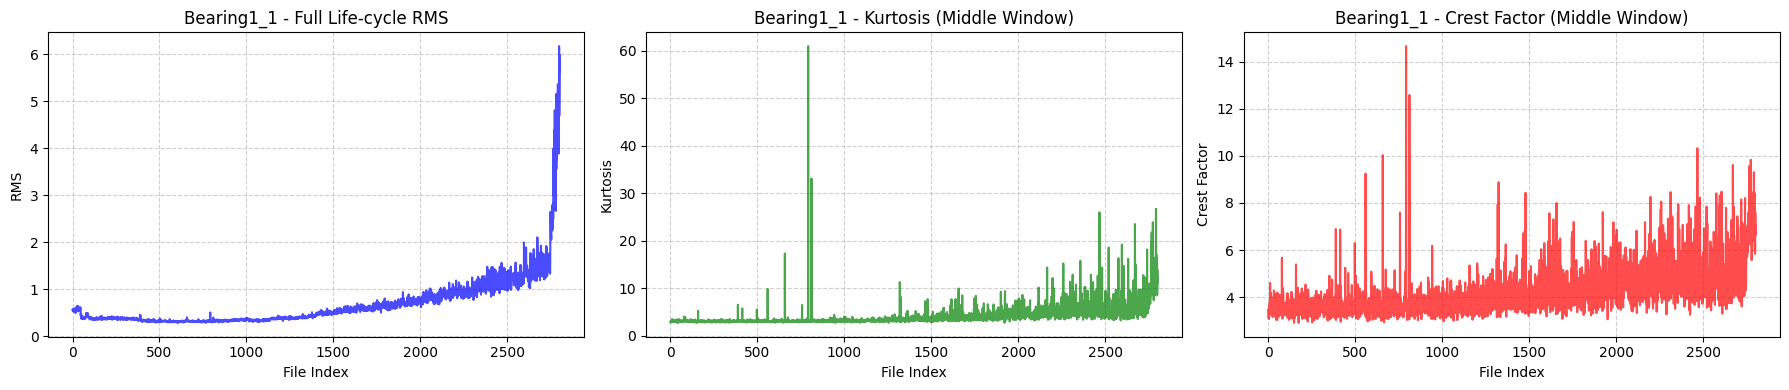

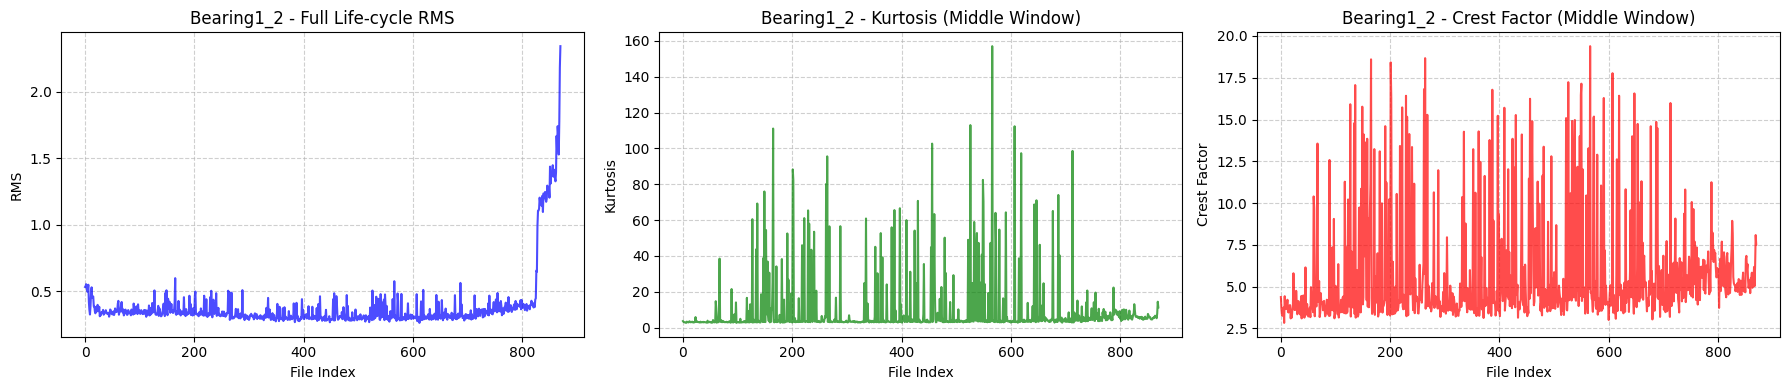

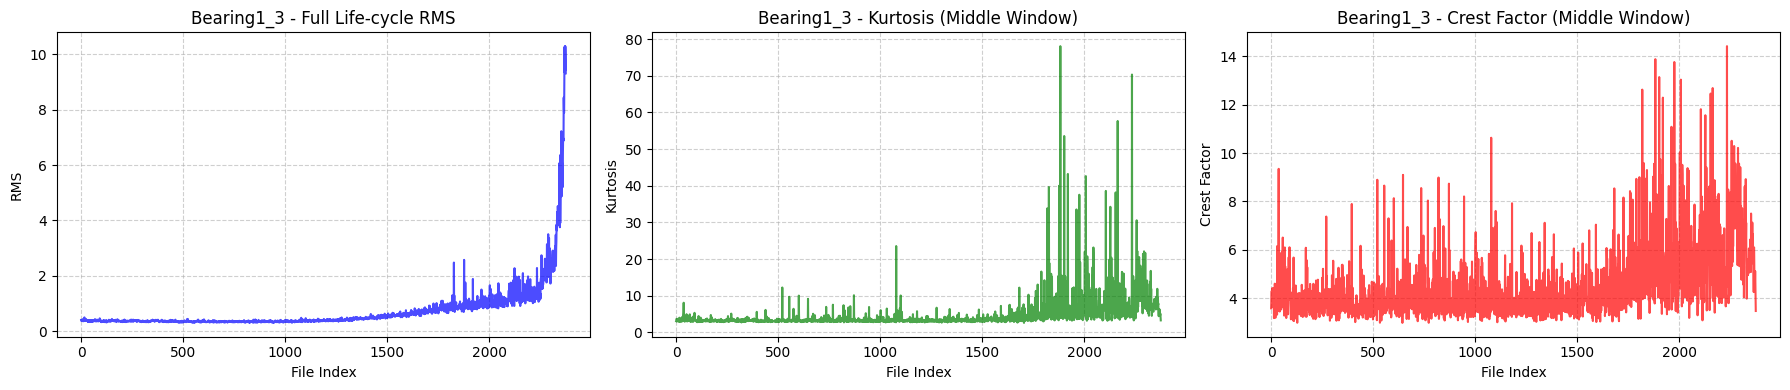

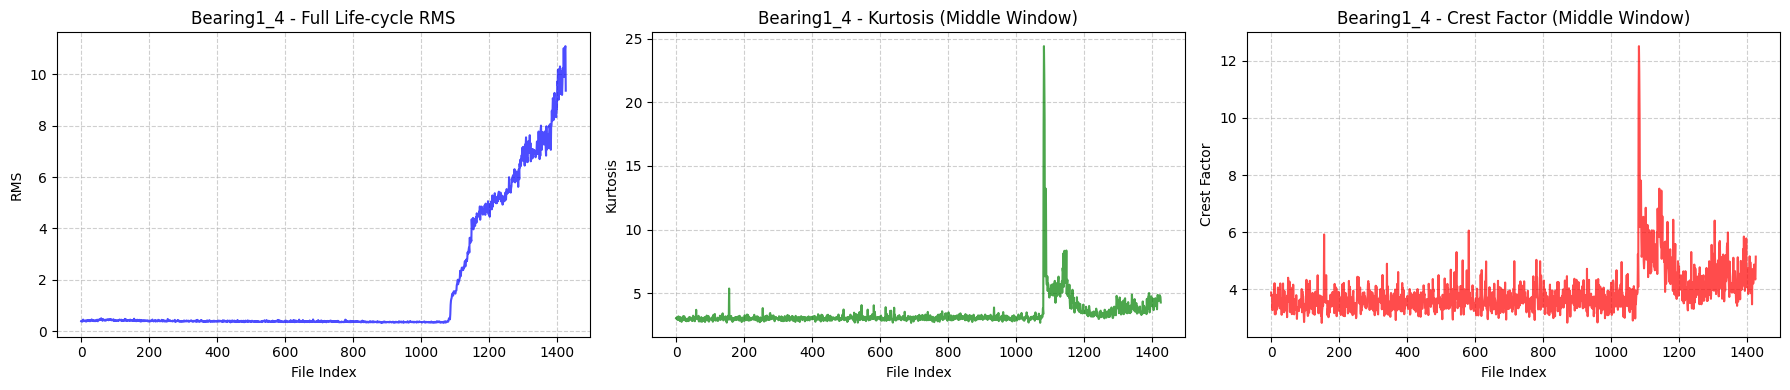

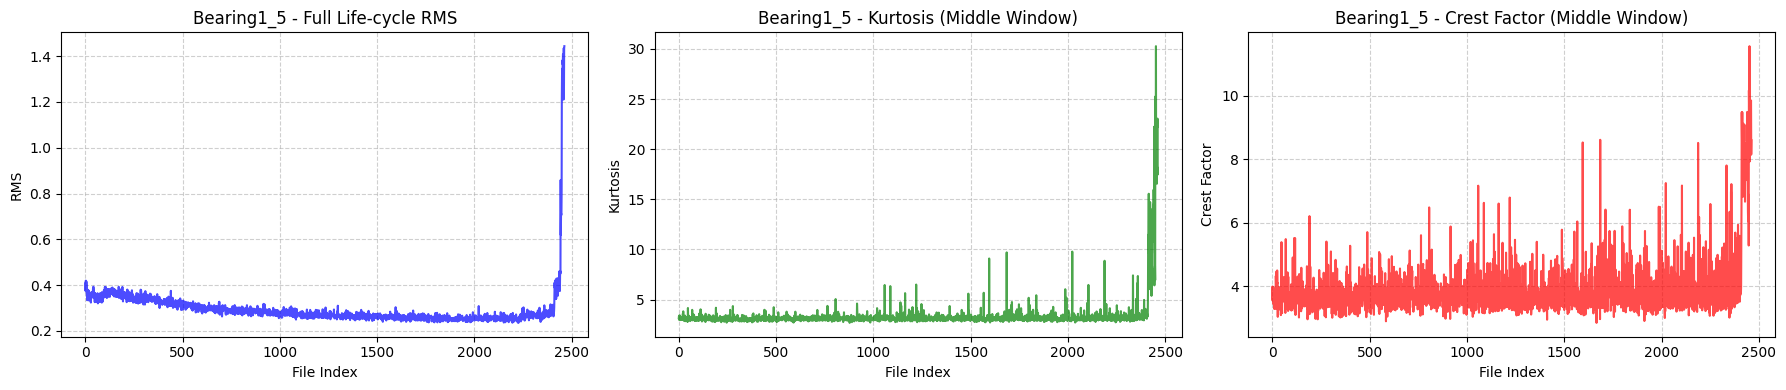

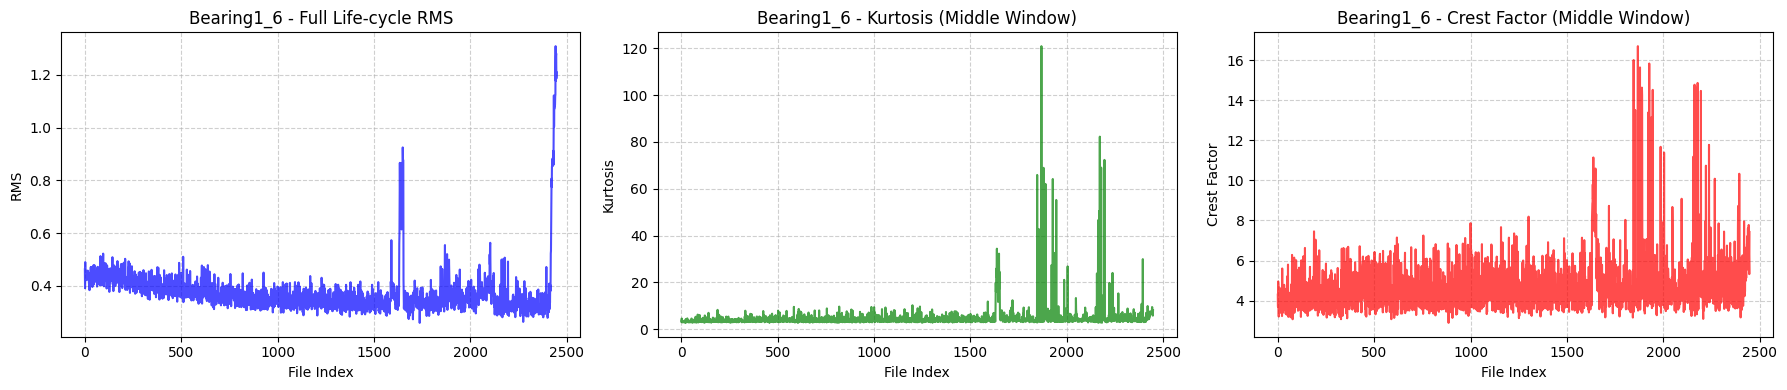

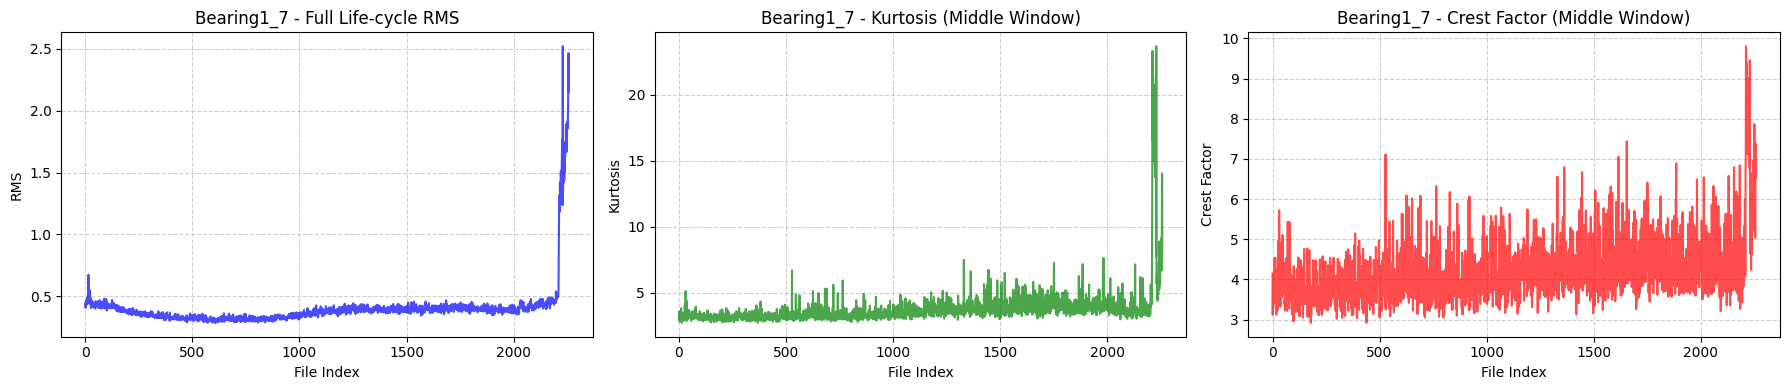

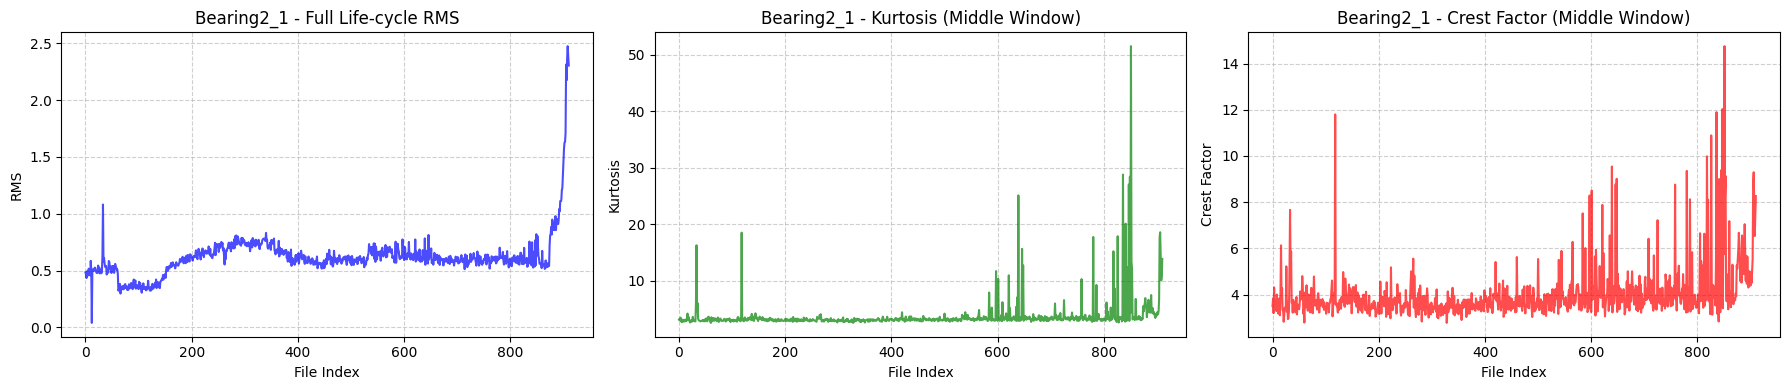

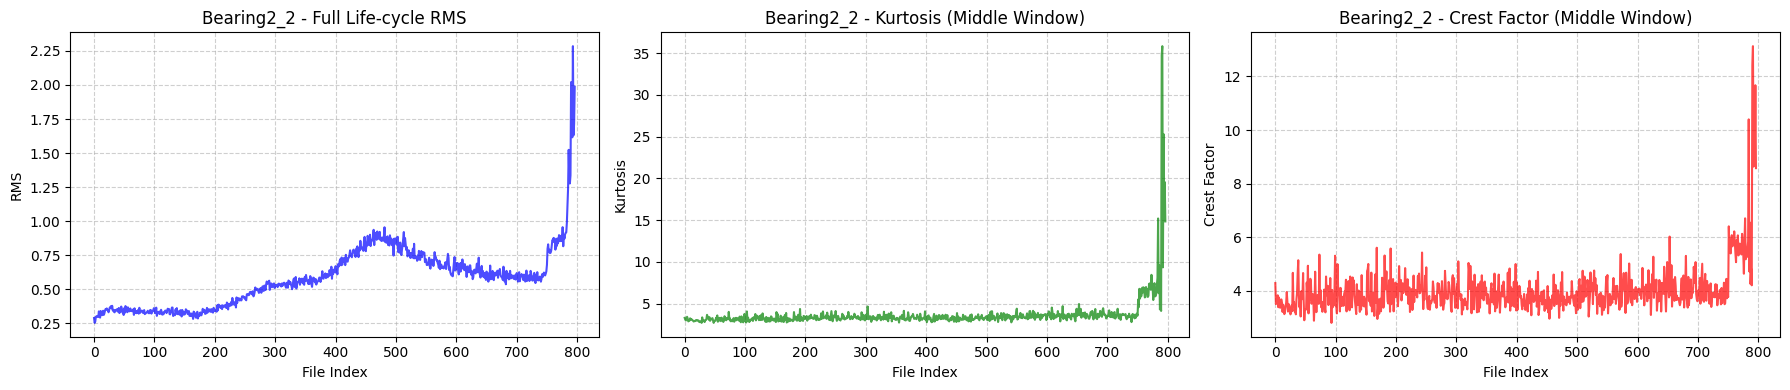

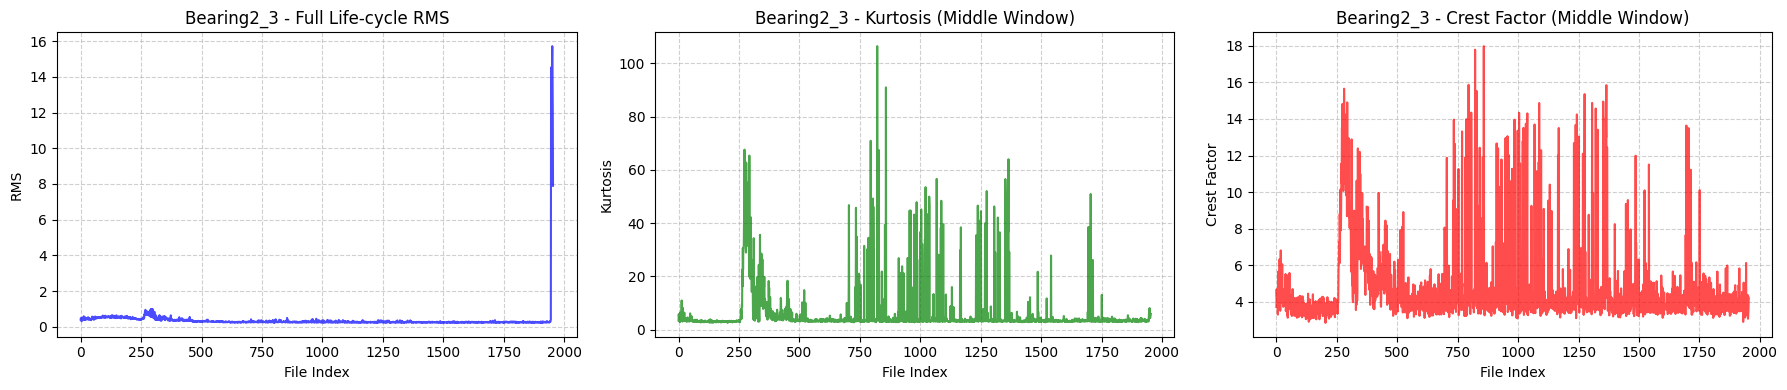

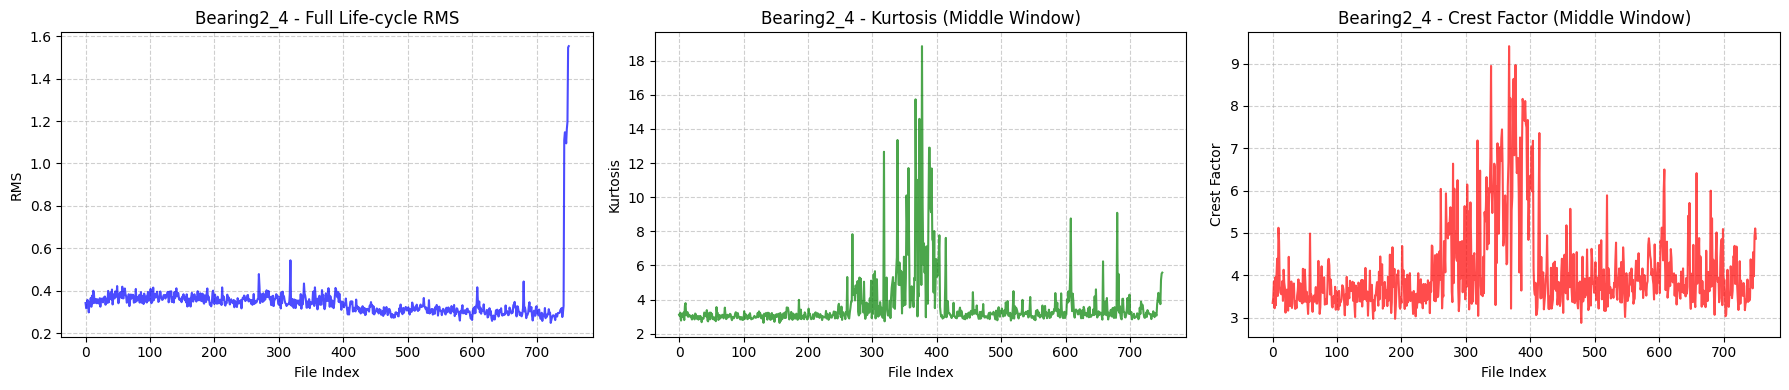

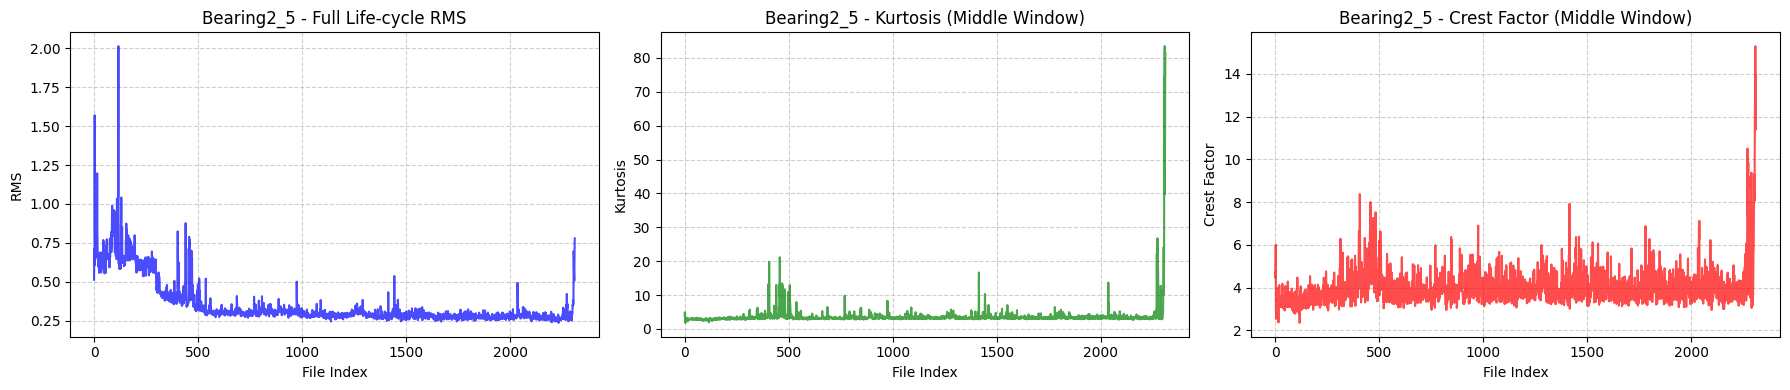

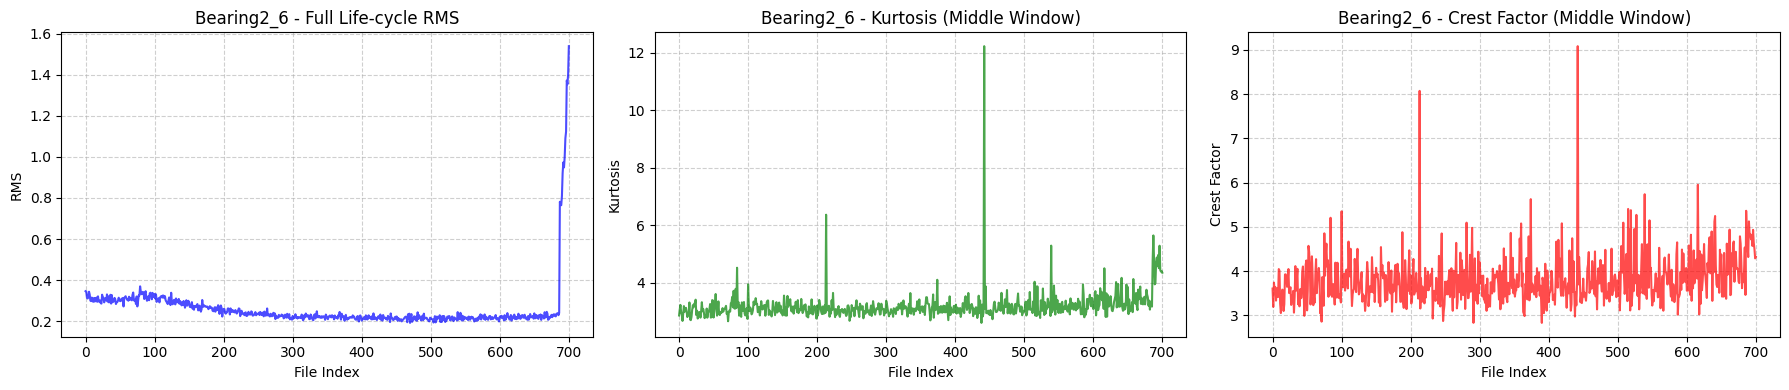

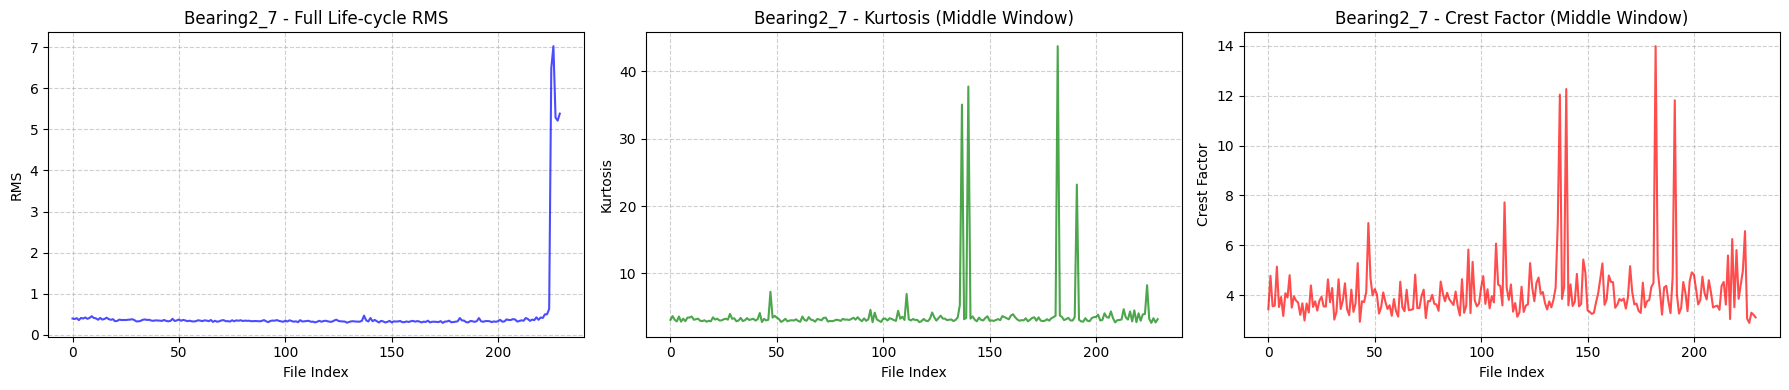

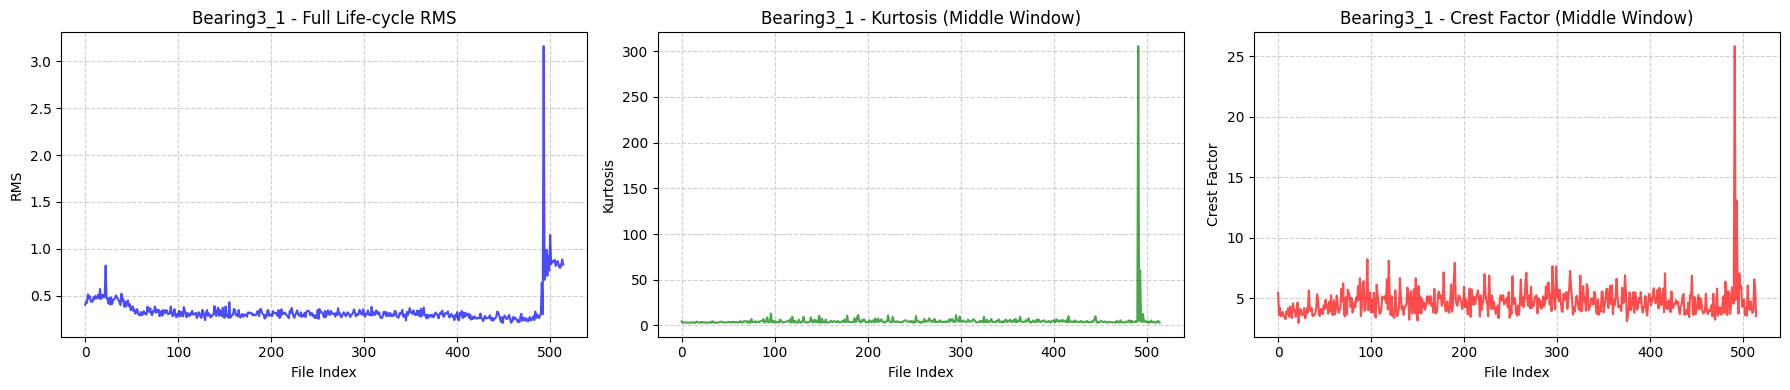

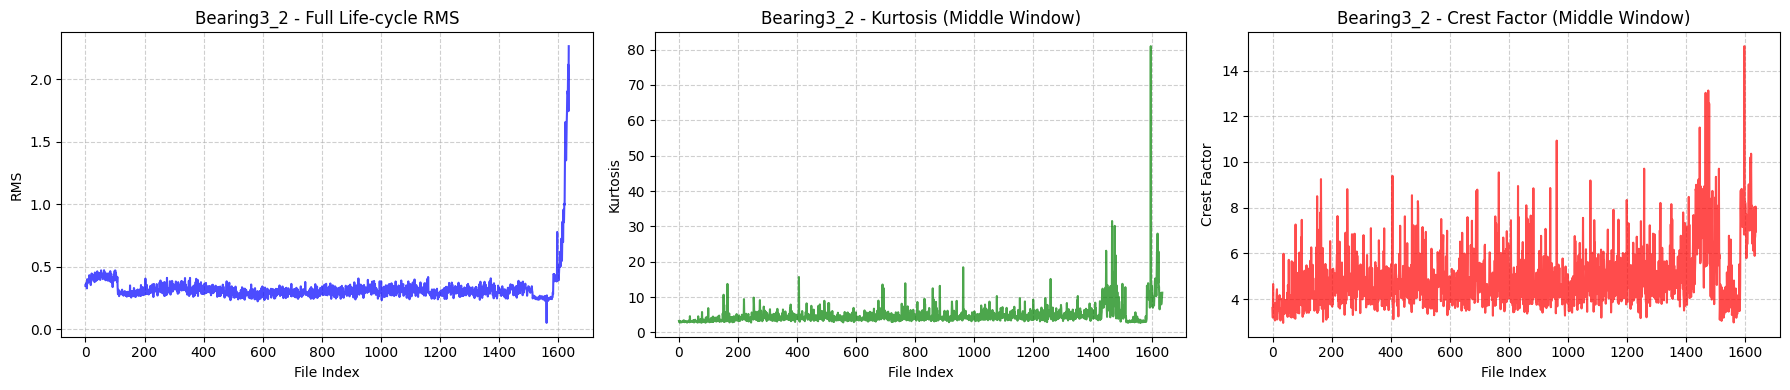

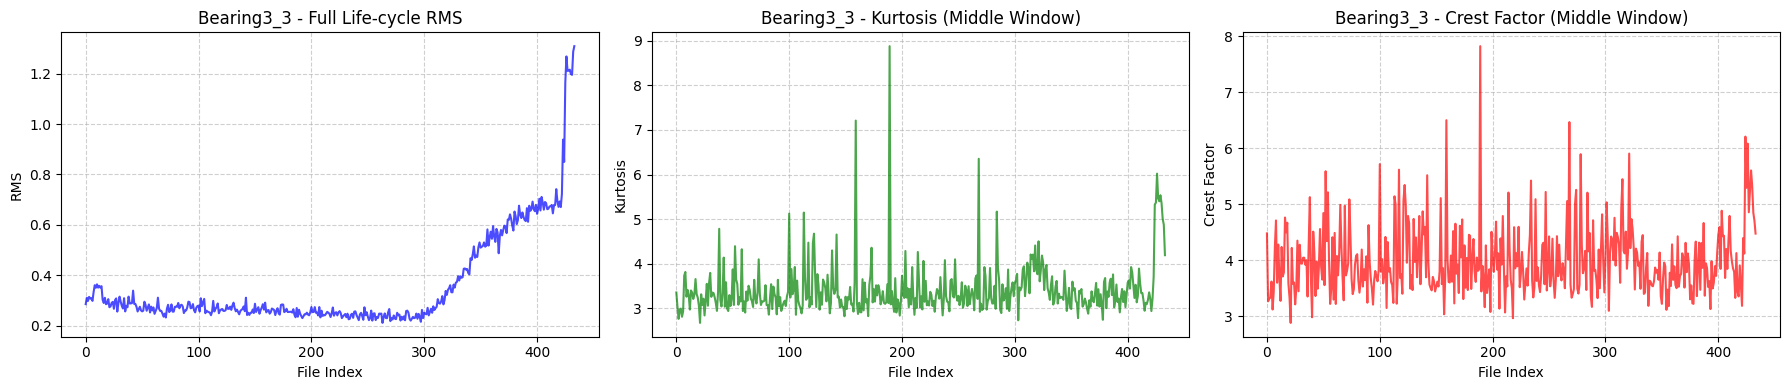

In [7]:
# --- Visualization of All Bearings ---
for b_id, features in all_bearing_features.items():
    plt.figure(figsize=(18, 4))
    
    # 1. RMS
    plt.subplot(1, 3, 1)
    plt.plot(features['indices'], features['rms'], color='blue', alpha=0.7)
    plt.title(f"{b_id} - Full Life-cycle RMS")
    plt.xlabel("File Index")
    plt.ylabel("RMS")
    plt.grid(True, linestyle='--', alpha=0.6)

    # 2. Kurtosis
    plt.subplot(1, 3, 2)
    plt.plot(features['indices'], features['kurtosis'], color='green', alpha=0.7)
    plt.title(f"{b_id} - Kurtosis (Middle Window)")
    plt.xlabel("File Index")
    plt.ylabel("Kurtosis")
    plt.grid(True, linestyle='--', alpha=0.6)

    # 3. Crest Factor
    plt.subplot(1, 3, 3)
    plt.plot(features['indices'], features['crest_factor'], color='red', alpha=0.7)
    plt.title(f"{b_id} - Crest Factor (Middle Window)")
    plt.xlabel("File Index")
    plt.ylabel("Crest Factor")
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
